In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import geodatasets as gd
import folium as fl
import mapclassify

In [4]:
world = gpd.read_file("ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp")

In [5]:
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,3,Zimbabwe,ZWE,0,2,Sovereign country,1,Zimbabwe,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((31.28789 -22.40205, 31.19727 -22.344..."
1,Admin-0 country,1,3,Zambia,ZMB,0,2,Sovereign country,1,Zambia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((30.39609 -15.64307, 30.25068 -15.643..."
2,Admin-0 country,1,3,Yemen,YEM,0,2,Sovereign country,1,Yemen,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((53.08564 16.64839, 52.58145 16..."
3,Admin-0 country,3,2,Vietnam,VNM,0,2,Sovereign country,1,Vietnam,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((104.06396 10.39082, 104.08301 ..."
4,Admin-0 country,5,3,Venezuela,VEN,0,2,Sovereign country,1,Venezuela,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-60.82119 9.13838, -60.94141 9..."


Plotting world Map with geopandas

<Axes: >

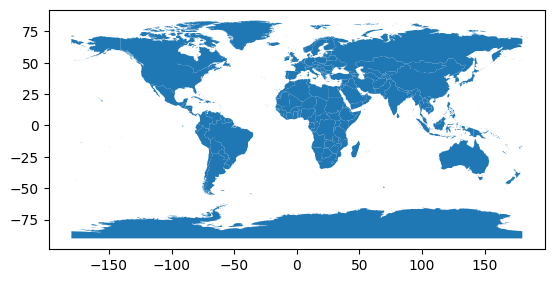

In [6]:
world.plot()

In [8]:
type(world)

geopandas.geodataframe.GeoDataFrame

In [10]:
world.columns

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)

In [12]:
world.geometry.head()

0    POLYGON ((31.28789 -22.40205, 31.19727 -22.344...
1    POLYGON ((30.39609 -15.64307, 30.25068 -15.643...
2    MULTIPOLYGON (((53.08564 16.64839, 52.58145 16...
3    MULTIPOLYGON (((104.06396 10.39082, 104.08301 ...
4    MULTIPOLYGON (((-60.82119 9.13838, -60.94141 9...
Name: geometry, dtype: geometry

In [14]:
world.geom_type.value_counts()

Polygon         123
MultiPolygon    119
Name: count, dtype: int64

Accessing specific geometry of country

<Figure size 1000x800 with 0 Axes>

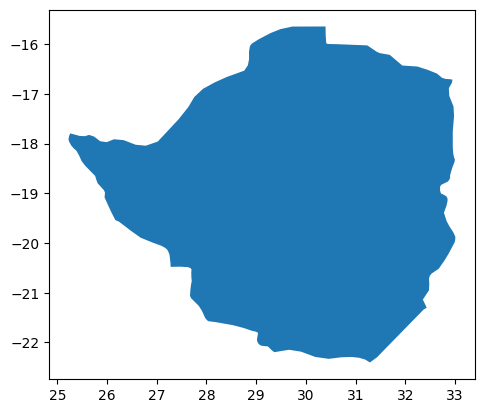

In [16]:
country_shape = world.geometry.iloc[0]

plt.figure(figsize = (10,8))
gpd.GeoSeries(country_shape).plot()

plt.show()

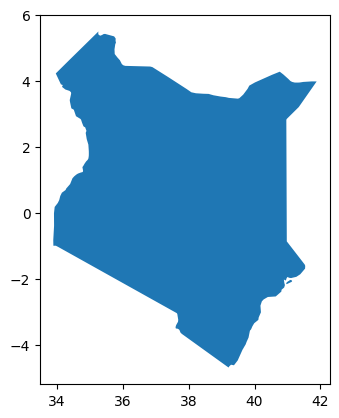

In [22]:
kenya = world[world['ADMIN'] == 'Kenya']
kenya.geometry.plot()
plt.show()


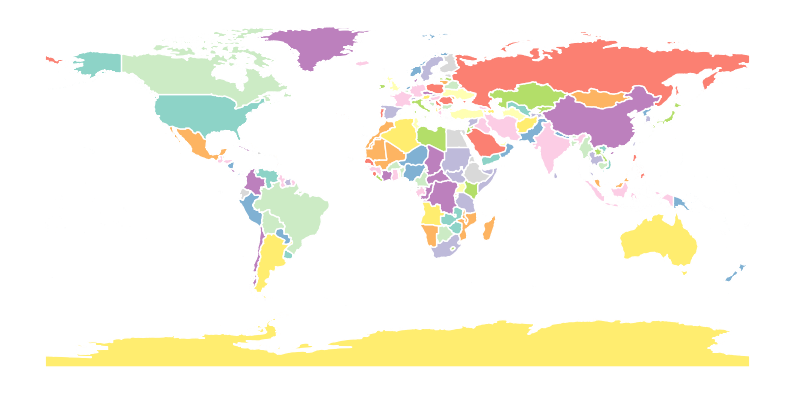

In [24]:
ax = world.plot(figsize = (10,5), cmap = 'Set3', edgecolor = 'white')
ax.axis('off')

plt.show()

In [26]:
airbnb = gpd.read_file(gd.get_path('geoda.airbnb'))
airbnb.head()

,community,shape_area,shape_len,AREAID,response_r,accept_r,rev_rating,price_pp,room_type,num_spots,...,crowded,dependency,without_hs,unemployed,income_pc,harship_in,num_crimes,num_theft,population,geometry
0,DOUGLAS,46004621.1581,31027.0545098,35,98.771429,94.514286,87.777778,78.157895,1.789474,38,...,1.8,30.7,14.3,18.2,23791,47,5013,1241,18238,"POLYGON ((-87.60914 41.84469, -87.60915 41.844..."
1,OAKLAND,16913961.0408,19565.5061533,36,99.200000,90.105263,88.812500,53.775000,1.850000,20,...,1.3,40.4,18.4,28.7,19252,78,1306,311,5918,"POLYGON ((-87.59215 41.81693, -87.59231 41.816..."
2,FULLER PARK,19916704.8692,NaN,37,68.000000,NaN,91.750000,84.000000,1.833333,6,...,3.2,44.9,26.6,33.9,10432,97,1764,383,2876,"POLYGON ((-87.6288 41.80189, -87.62879 41.8017..."
3,GRAND BOULEVARD,48492503.1554,28196.8371573,38,94.037037,83.615385,92.750000,119.533333,1.533333,30,...,3.3,39.5,15.9,24.3,23472,57,6416,1428,21929,"POLYGON ((-87.60671 41.81681, -87.6067 41.8165..."
4,KENWOOD,29071741.9283,23325.1679062,39,92.542857,88.142857,90.656250,77.991453,1.615385,39,...,2.4,35.4,11.3,15.7,35911,26,2713,654,17841,"POLYGON ((-87.59215 41.81693, -87.59215 41.816..."


<Axes: >

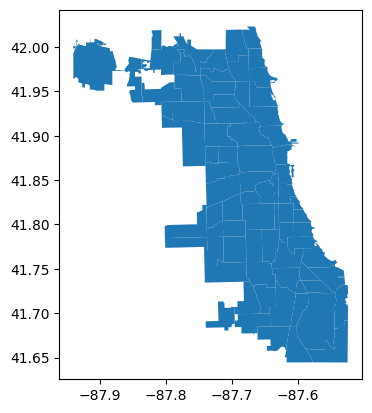

In [27]:
airbnb.plot()

<Axes: >

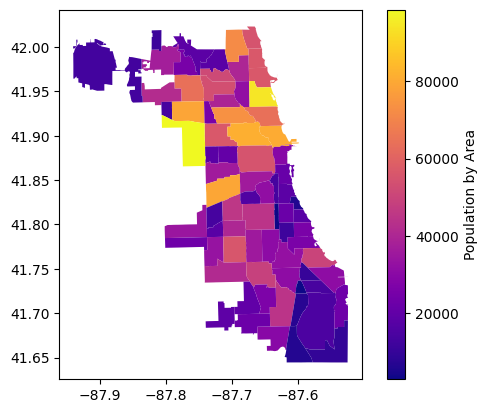

In [33]:
airbnb.plot(
    column = 'population', 
    legend = True, 
    legend_kwds = {'label':'Population by Area'},
    cmap = 'plasma'
)

<Axes: >

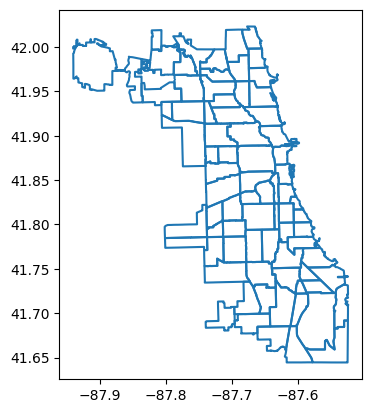

In [34]:
airbnb.boundary.plot()

In [3]:
atlanta = gpd.read_file(gd.get_path('geoda.atlanta'))
atlanta.head()

,NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,FIPS,STFIPS,COFIPS,FIPSNO,HR7983,HR8587,...,PO7983,PO8587,PO8995,PE77,PE82,PE87,RDAC80,RDAC85,RDAC90,geometry
0,Cherokee,North Carolina,37,039,37039,37,39,37039,6.298816,6.742065,...,95256,59329,144758,2.933480,1.605377,1.922455,0.897757,0.444341,0.134578,"POLYGON ((-84.29104 35.21054, -84.22594 35.261..."
1,Polk,Tennessee,47,139,47139,47,139,47139,13.271204,9.629968,...,67816,41537,97210,4.422696,3.994711,3.833682,-0.012454,-0.140179,-0.192610,"POLYGON ((-84.29104 35.21054, -84.32385 34.989..."
2,Oconee,South Carolina,45,073,45073,45,73,45073,14.174115,6.246720,...,246929,160084,413465,3.716055,3.635228,3.789255,-0.168537,-0.311719,-0.368479,"POLYGON ((-83.05512 34.48996, -83.07915 34.518..."
3,Rabun,Georgia,13,241,13241,13,241,13241,13.306214,6.038830,...,52607,33119,83962,2.637461,2.625957,4.394626,0.449209,0.058768,-0.229536,"POLYGON ((-83.3508 34.70955, -83.39137 34.7288..."
4,Whitfield,Georgia,13,313,13313,13,313,13313,10.274169,6.715627,...,330927,208469,524696,4.099088,2.877935,2.452316,-0.318807,-0.476584,-0.566740,"POLYGON ((-85.047 34.62268, -85.04798 34.71451..."


<Axes: >

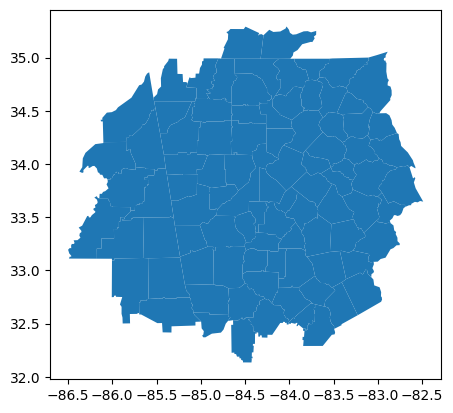

In [9]:
atlanta.plot()

In [10]:
atlanta.explore()

In [3]:
atlanta.explore(
    column = 'HC7983',
    cmap = 'Reds',
    legend = True,
    tootip = ['NAME','HC7983'],
    style_kwds = {'fillOpacity': 0.6, 'weight': 0.8},
    highlight = False
)

Creating a folium map

In [4]:
map_centre = [atlanta.geometry.centroid.y.mean(), atlanta.geometry.centroid.x.mean()]
m = fl.Map(location = map_centre, zoom_start = 6)
m

C:\Users\victo\AppData\Local\Temp\ipykernel_23560\757492793.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  map_centre = [atlanta.geometry.centroid.y.mean(), atlanta.geometry.centroid.x.mean()]


In [6]:
fl.Marker(
    location = [33.7490, -84.3880],
    popup = 'Downtown Atlanta',
    tooltip = 'Click Me'
).add_to(m)

m

In [8]:
top5 = atlanta.nlargest(5,'HR8995')

for _, row in top5.iterrows():
    location = [row.geometry.centroid.y, row.geometry.centroid.x]
    rate = row['HR8995']
    name = row['NAME']

    fl.CircleMarker(
        location = location,
        radius = 5 + rate/5,
        color = 'crimson',
        fill = True,
        fill_opacity = 0.8,
        popup=f"{name} County<br>Homicide Rate: {rate:.1f}"
    ).add_to(m)

m